# Rozdzielczość obrazu. Interpolacja.

## Cel zajęć:

* zapoznanie z pojęciem rozdzielczości przestrzennej (rozmiaru obrazu),
* metody interpolacji najbliższego sąsiada oraz dwuliniowa,
* zapoznanie z pojęciem rozdzielczości dpi (ang. dots per inch),
* zapoznanie z pojęciem rozdzielczości  poziomów jasności (dla obrazów w skali szarości),
* zadanie domowe: interpolacja dwusześcienna.

## Rodzielczość przestrzenna

Dyskretna reprezentacja obrazu to zwykle macierz dwu (N x M - obraz w skali szarości) lub trójwymiarowa (N x M x 3 - obraz kolorowy).
Przez rozdzielczość przestrzenną rozumie się liczbę pikseli z których składa się obraz.
Przykładowo rozdzielczość VGA to  640 x 480, Full HD to 1920 x 1080, a 4K to 3840 x 2160.
Rozdzielczość obrazu można modyfikować (zwiększać/zmniejszać), co nazywa się skalowaniem obrazu.
Warto wiedzieć, że zwiększenie rozdzielczości obrazu nie zwiększa ilości informacji, a jedynie liczbę pikseli (w sensie "lepiej nie będzie").
Ponadto skalowanie zawsze wprowadza pewne zniekształcenia, nawet przy zmniejszaniu rozmiaru.

W ramach niniejszego ćwiczenia zapoznamy się z metodami interpolacji, które są podstawą takich operacji jak: przybliżanie (zoom), zmiana rozdzielczości, rotacja obrazu, czy też korekcje geometryczne.
Jako przykład posłuży nam zmiana rozdzielczości, czyli inaczej mówiąc przepróbkowanie obrazu.
Dla przypomnienia - interpolacja to wykorzystanie znanych danych (wartości dla tzw. punktów węzłowych) do określania wartości w nieznanych lokalizacjach.

Zacznijmy od prostego przykładu.
Mamy obraz o rozdzielczości 500 x 500 pikseli, a chcemy go powiększyć do 750 x 750 pikseli -- tj. o~współczynnik 1,5.
Wyobraźmy sobie zatem, że dysponujemy siatką 750 x 750 o takim samym "rozmiarze" pojedynczego piksela jak obraz oryginalny.
Następnie siatkę tą ,,ścieśniamy'', tak aby miała rozmiar 500 x 500.
W rezultacie otrzymana siatka będzie miała mniejszy rozmiar pojedynczego piksela niż obraz oryginalny.
Schematycznie przedstawiono to na poniższym rysunku.

![Ilustracja interpolacji](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/interEx57.png)


Pokazuje on przykład interpolacji: a) obraz 5x5, b) oraz 7x7, c) obraz 7x7 zmiejszony do 5x5.


Chcemy teraz poszczególnym elementom nowej siatki przyporządkować piksele z obrazu wejściowego.
Jedną z możliwości jest poszukanie "najbliższego" piksela w oryginalnym obrazie i wzięcie jego wartości.
Przykład takiego postępowania zaprezentowano na  poniższym rysunku.

![Ilustracja najbliższego sąsiada](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/inteNNEx.png)

Kilka słów wyjasnienia.
Kolorem ciemnoszarym oznaczono siatkę 5x5, a czarnym 7x7 (już po przeskalowaniu).
Nasze zadanie sprowadza się do znalezienia dla każdej kropki czarnej (umowny środek piksela), najbliżej leżącej kropki szarej - oznaczono to dla pierwszych trzech wierzszy obrazu liniami.

Po zrealizowaniu powyższego kroku dla całego obrazu wykonujemy "rozciągniecie" do rozdzielczości 750 x 750.
W ten sposób uzyskujemy finalny efekt zmiany rozdzielczości.

## Interpolacja metodą najbliższego sąsiada

Takie postępowanie określa się mianem **interpolacji metodą najbliższego sąsiada** (ang. *nearest neighbour interpolation*).
W ramach pierwszego etapu ćwiczenia zaimplementujemy to podejście.

1. Ładujemy potrzebne biblioteki, pobieramy obrazy z repozytorium, wczytujemy jeden z obrazów testowych (*parrot.bmp*) i wyświetlamy go:

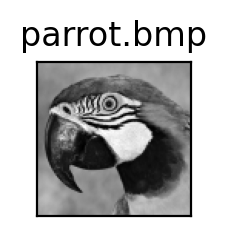

In [3]:
import cv2
import os
from matplotlib import pyplot as plt
import numpy as np

if not os.path.exists("parrot.bmp"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/parrot.bmp --no-check-certificate
if not os.path.exists("clock.bmp"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/clock.bmp --no-check-certificate
if not os.path.exists("chessboard.bmp"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/chessboard.bmp --no-check-certificate
if not os.path.exists("lena.bmp"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/lena.bmp --no-check-certificate
if not os.path.exists("firetruck.jpg"):
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/firetruck.jpg --no-check-certificate

# Lista wszystkich obrazów
image_files = ['clock.bmp', 'parrot.bmp', 'chessboard.bmp', 'lena.bmp', 'firetruck.jpg']

# Wczytujemy wszystkie obrazy do słownika
images = {}
for file in image_files:
    if file.endswith('.jpg'):
        img = cv2.imread(file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
    images[file] = img

# Wyświetlamy tylko obraz parrot.bmp
parrot_img = images['parrot.bmp']
plt.figure(figsize=(parrot_img.shape[1]/100, parrot_img.shape[0]/100), dpi=200)
plt.imshow(parrot_img, cmap="gray")
plt.title('parrot.bmp')
plt.xticks([]), plt.yticks([])
plt.show()

2. Definiujemy funkcję do interpolacji metodą najbliższego sąsiada.

Jako argumenty wejściowe powinna ona przyjąć obraz oraz współczynniki skalowania w pionie i poziomie.
Wyjściem powinien być natomiast obraz w nowej rozdzielczości.
Wewnątrz należy:

* odczytać wymiary obrazka wejściowego,
* wyliczyć wymiary obrazka wyjściowego (tj. wymnożyć wymiary wejściowe przez skalę i zaokrąglić do liczb całkowitych),
* utworzyć nowy obraz o ww. rozmiarze,
* w pętli po nowym obrazie, dla każdego piksela, wykorzystując współczynniki skalowania, odnaleźć najbliższego sąsiada.




In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def najblizszy_sasiad_interpolacji(image, scale_x, scale_y):
    """
    Funkcja dokonująca interpolacji obrazu metodą najbliższego sąsiada.
    
    Parametry:
    image - obraz wejściowy
    scale_x - współczynnik skalowania w poziomie
    scale_y - współczynnik skalowania w pionie
    
    Zwraca:
    resized_image - przeskalowany obraz
    """
    if len(image.shape) == 2: 
        height, width = image.shape
    else:  
        height, width, _ = image.shape
    
    new_height = int(round(height * scale_y))
    new_width = int(round(width * scale_x))
    
    if len(image.shape) == 2:
        resized_image = np.zeros((new_height, new_width), dtype=image.dtype)
    else:
        resized_image = np.zeros((new_height, new_width, image.shape[2]), dtype=image.dtype)
    
    for i in range(new_height):
        y = min(int(i / scale_y), height - 1)  # Znajdź najbliższy piksel y
        for j in range(new_width):
            x = min(int(j / scale_x), width - 1)  # Znajdź najbliższy piksel x
            resized_image[i, j] = image[y, x]
    
    return resized_image

# Funkcja pomocnicza do wyświetlania
def show_interpolation_result(image, interpolated_image, title, scale_x, scale_y):
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title('Oryginalny: ' + title)
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(image)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f'Interpolowany ({scale_x}x, {scale_y}x): ' + title)
    if len(interpolated_image.shape) == 2:
        plt.imshow(interpolated_image, cmap='gray')
    else:
        plt.imshow(interpolated_image)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

3. Testujemy stworzoną funkcję:
    * dla skali 1.5, 1.5 i obrazka *parrot*,
    * dla 2.5, 2.5 - tu okaże się, że do kodu trzeba dopisać zabezpieczenie przed wyjściem poza zakres,
    * dla niejednakowych skal np. 1.5 i 2.5,
    * dla skal mniejszych od 1,
    * dla niesymetrycznego obrazka *clock*,
    * dla obrazka z szachownicą *chessboard*.

Uwaga: proszę dla powyższych przypadków przygotować osobne sekcje kodu - tak, aby wyświetlały się wszystkie rozważane przypadki.

Wykonana metoda jest bardzo prosta i szybka, ale wprowadza pewne niepożądane artefakty, w szczególnie źle odwzorowane są linie proste.
Z drugiej strony sprawdza się w pewnych nietypowych przypadkach.
Zostanie to zademonstrowane w dalszej części ćwiczenia.

Test 1: Obraz 'parrot' ze skalą 1.5, 1.5


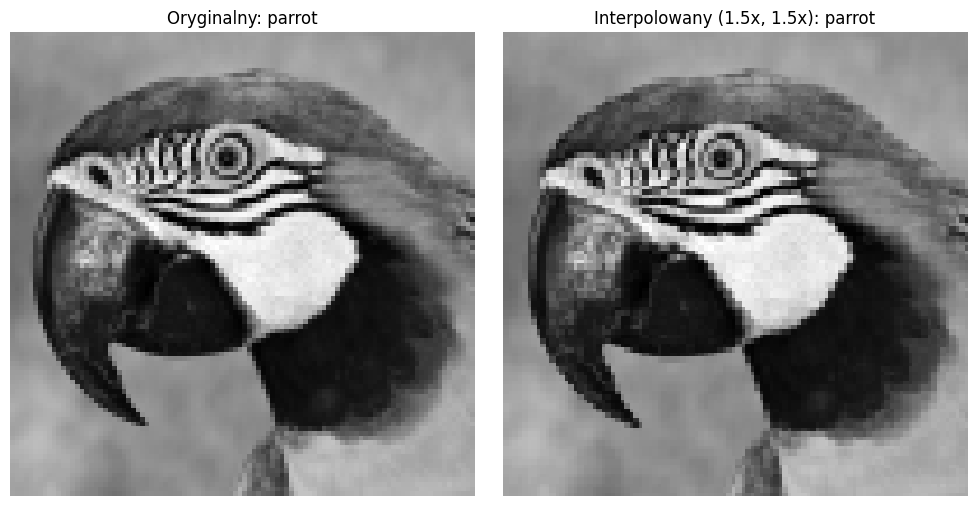

Test 2: Obraz 'parrot' ze skalą 2.5, 2.5


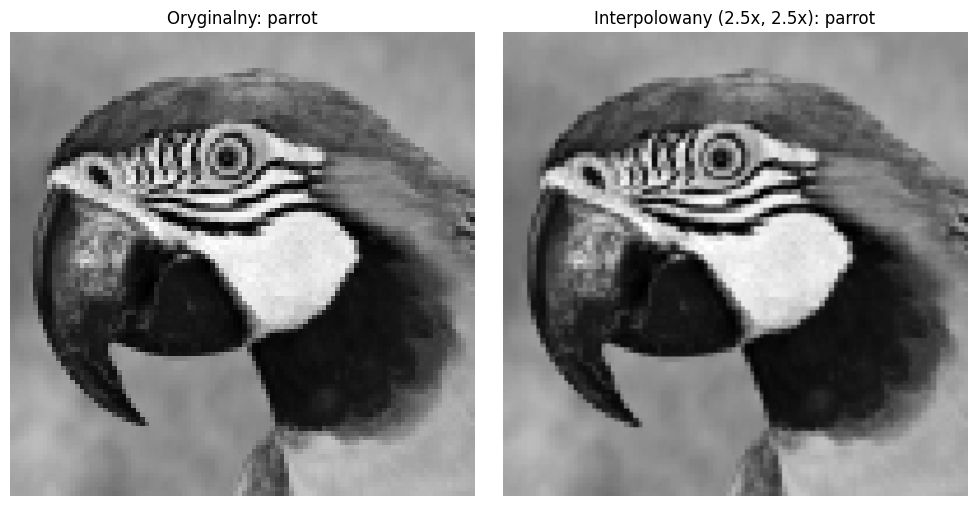

Test 3: Obraz 'parrot' z niejednakową skalą 1.5, 2.5


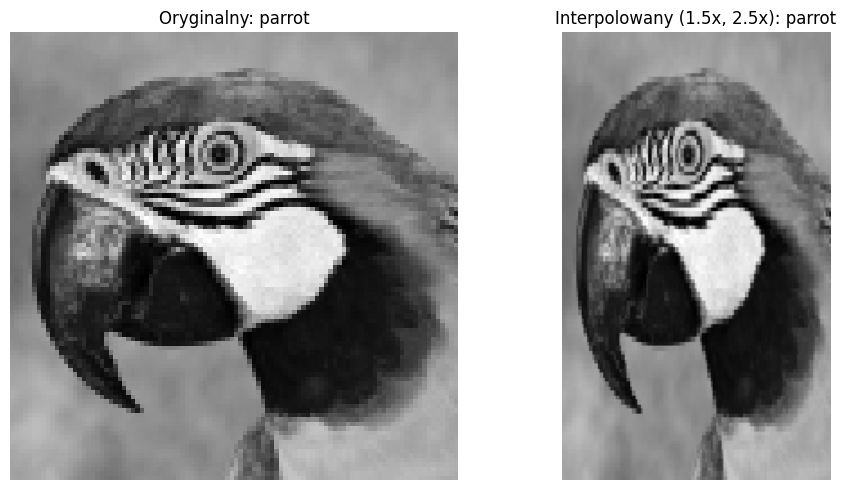

Test 4: Obraz 'parrot' ze skalą 0.7, 0.7


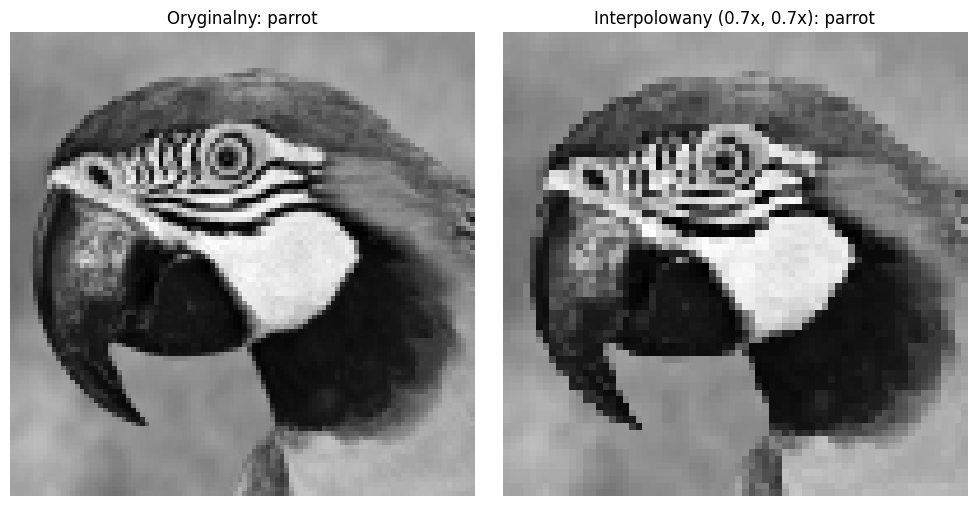

Test 5: Niesymetryczny obraz 'clock', skala 1.5, 1.5


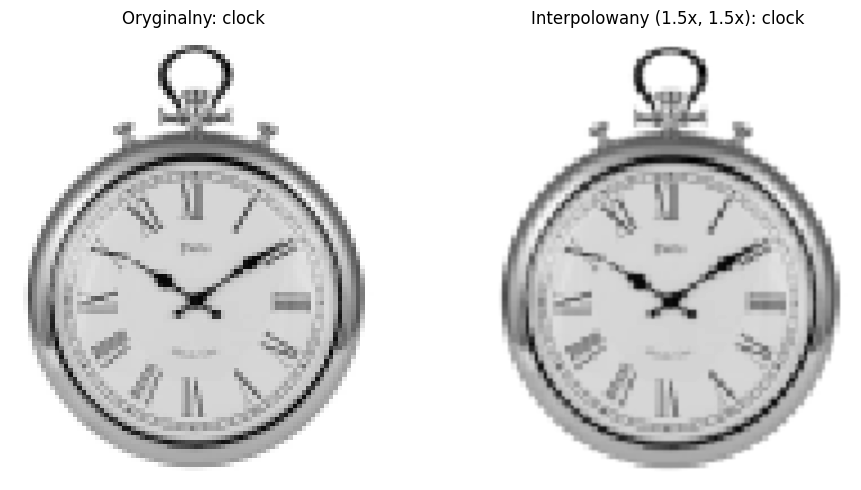

Test 6: Obraz szachownicy 'chessboard', skala 1.5, 1.5


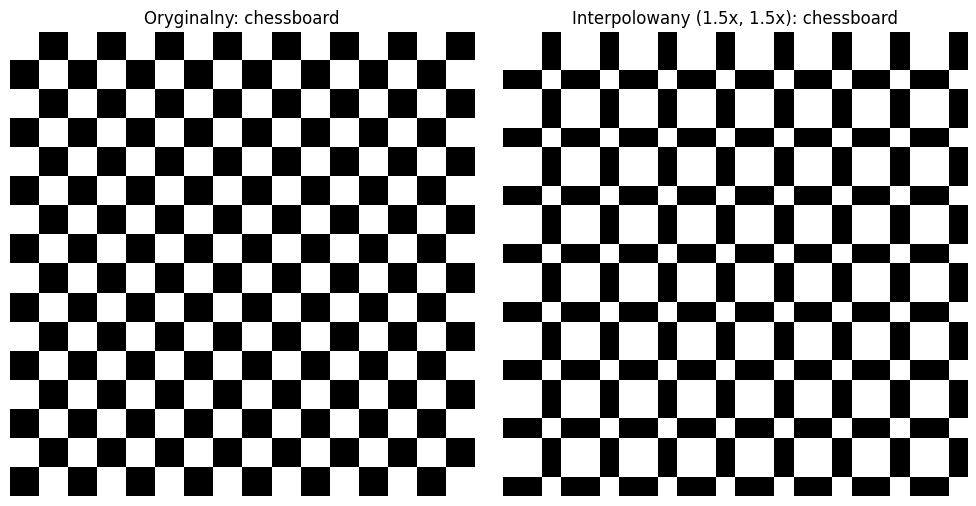

In [5]:
# Wczytywanie obrazów
parrot = cv2.imread('parrot.bmp', cv2.IMREAD_GRAYSCALE)
clock = cv2.imread('clock.bmp', cv2.IMREAD_GRAYSCALE)
chessboard = cv2.imread('chessboard.bmp', cv2.IMREAD_GRAYSCALE)

# 1. Test dla obrazka "parrot" ze skalą 1.5, 1.5
print("Test 1: Obraz 'parrot' ze skalą 1.5, 1.5")
scale_x, scale_y = 1.5, 1.5
interpolated_parrot_1 = najblizszy_sasiad_interpolacji(parrot, scale_x, scale_y)
show_interpolation_result(parrot, interpolated_parrot_1, "parrot", scale_x, scale_y)

# 2. Test dla obrazka "parrot" ze skalą 2.5, 2.5 (sprawdzenie zabezpieczeń przed wyjściem poza zakres)
print("Test 2: Obraz 'parrot' ze skalą 2.5, 2.5")
scale_x, scale_y = 2.5, 2.5
interpolated_parrot_2 = najblizszy_sasiad_interpolacji(parrot, scale_x, scale_y)
show_interpolation_result(parrot, interpolated_parrot_2, "parrot", scale_x, scale_y)

# 3. Test dla obrazka "parrot" z niejednakową skalą 1.5, 2.5
print("Test 3: Obraz 'parrot' z niejednakową skalą 1.5, 2.5")
scale_x, scale_y = 1.5, 2.5
interpolated_parrot_3 = najblizszy_sasiad_interpolacji(parrot, scale_x, scale_y)
show_interpolation_result(parrot, interpolated_parrot_3, "parrot", scale_x, scale_y)

# 4. Test dla obrazka "parrot" ze skalą mniejszą od 1 (0.7, 0.7)
print("Test 4: Obraz 'parrot' ze skalą 0.7, 0.7")
scale_x, scale_y = 0.7, 0.7
interpolated_parrot_4 = najblizszy_sasiad_interpolacji(parrot, scale_x, scale_y)
show_interpolation_result(parrot, interpolated_parrot_4, "parrot", scale_x, scale_y)

# 5. Test dla niesymetrycznego obrazka "clock"
print("Test 5: Niesymetryczny obraz 'clock', skala 1.5, 1.5")
scale_x, scale_y = 1.5, 1.5
interpolated_clock = najblizszy_sasiad_interpolacji(clock, scale_x, scale_y)
show_interpolation_result(clock, interpolated_clock, "clock", scale_x, scale_y)

# 6. Test dla obrazka z szachownicą "chessboard"
print("Test 6: Obraz szachownicy 'chessboard', skala 1.5, 1.5")
scale_x, scale_y = 1.5, 1.5
interpolated_chessboard = najblizszy_sasiad_interpolacji(chessboard, scale_x, scale_y)
show_interpolation_result(chessboard, interpolated_chessboard, "chessboard", scale_x, scale_y)

## Interpolacja dwuliniowa

W praktyce, lepszym rozwiązaniem zwykle okazuje tzw. **interpolacja dwuliniowa** (ang. *bilinear interpolation*).
Wykorzystuje ona informację o czterech najbliższych sąsiadach do określenia nowej wartości piksela.

Jeśli przez $(i,j)$ oznaczymy współrzędne poszukiwanego piksela, a przez $I(i,j)$ jego jasność (składową w~odcieniach szarości) to jego wartość można obliczyć wykorzystując równanie:
\begin{equation}
I(i,j) = a \cdot i + b \cdot j+ c \cdot i \cdot j + d
\tag{1}
\end{equation}
gdzie: współczynniki $a,b,c,d$ można wyliczyć na podstawie czterech najbliższych sąsiadów.

![Ilustracja dwuliniowej](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/interABCD.png)

Prześledźmy to na przykładzie z powyższego rysunku.
Niech współrzędne poszczególnych punktów to $A = (j_1,i_1)$, $B = (j_1,i_2)$, $C= (j_2,i_2)$ oraz $D = (j_2,i_1)$.
W pierwszej kolejności dokonujemy interpolacji wartości w punktach $AB$ i $CD$ -- czyli poziomo.
Wychodząc od równania prostej otrzymujemy:

\begin{equation}
f(AB) \approx \frac{i_2 - i}{i_2-i_1}f(A) + \frac{i - i_1}{i_2-i_1}f(B)
\tag{2}
\end{equation}

\begin{equation}
f(CD) \approx \frac{i_2 - i}{i_2-i_1}f(D) + \frac{i - i_1}{i_2-i_1}f(C)
\tag{3}
\end{equation}

Następnie wykonujemy analogiczną interpolację w pionie:
\begin{equation}
f(ABCD) \approx \frac{j_2 - j}{j_2-j_1}f(AB) + \frac{j - j_1}{j_2-j_1}f(CD)
\tag{4}
\end{equation}

Łącząc powyższe równania otrzymujemy:
\begin{equation}
f(ABCD) \approx \frac{1}{(i_2 - i_1)(j_2-j_1)} ( f(A)(i_2-i)(j_2 - y) + f(B)(i-i_1)(j_2 - j) \\ + f(C)(i-i_1)(j-j_1) + f(D)(i_2-i)(j-j_1))
\tag{5}
\end{equation}
gdzie zapis $f(X)$ oznacza wartość piksela w punkcie $X$.

Rozważania można uprościć przyjmując, że narożniki rozpatrywanego kwadratu mają następujące współrzędne: $A = (0,0)$, $B = (0,1)$, $C= (1,1)$ oraz $D = (1,0)$.
Wtedy powyższe równanie można zapisać:
\begin{equation}
f(ABCD) \approx f(A)(1-i)(1-j) + f(B)i(1-j) + f(C)ij + f(D)(1-i)j
\tag{6}
\end{equation}

lub macierzowo:
\begin{equation}
f(ABCD) \approx \begin{bmatrix}1 - i & i \end{bmatrix} \begin{bmatrix} f(A) & f(D) \\\\ f(B) & f(C)  \end{bmatrix}   \begin{bmatrix} 1-j \\\\ j  \end{bmatrix}
\tag{7}
\end{equation}

Uwaga.
Nieco wbrew nazwie interpolacja dwuliniowa nie jest operacją liniową.
W złożeniu dwóch operacji liniowych pojawia się człon $xy$.

Warto dodać, że kolejny ``poziom wtajemniczenia'' to **interpolacja dwusześcienna** (ang. *bicubic interpolation*).
Dana jest ona wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\tag{8}
\end{equation}
Jej implementacja stanowi zadanie domowe do bieżącego ćwiczenia.

Trzy powyżej przedstawione metody bynajmniej nie wyczerpują tematu.
Wystarczy choćby otworzyć stronę [wiki o skalowaniu](https://en.wikipedia.org/wiki/Image_scaling), by zobaczyć, że metod jest dużo więcej.



Wykorzystując powyższe równania zaimplementuj interpolację dwuliniową:
* dobrym punktem wyjścia będzie stworzona funkcja do interpolacji metodą najbliższego sąsiada,
* początek powinien być identyczny,
* różnice rozpoczynają się w momencie obliczenia współrzędnych nowego piksela,
* jeśli chcemy zastosować opisane powyżej wzory (w wariancie uproszczonym), to musimy wyliczyć współrzędne punktów $A,B,C,D$,
* w pierwszym kroku obliczamy współrzędne $A$ tj. $(0,0)$ - należy do tego wykorzystać funkcję *floor* (np. $i_1 = floor(i / h_{scale})$).
  Proszę ten krok odnieść do przedstawionego rysunku poglądowego,
* obliczenie współrzędnych $B,C,D$ jest już proste i sprowadza się do operacji `+1`,
* potrzebujemy jeszcze część ułamkową współrzędnych punktu $ABCD$ tj. $(i,j)$ - od ilorazu $i/h_{scale}$ należy odjąć wartość $i_1$
* wykorzystując wyznaczone współrzędne, należy pobrać wartości jasności w punktach $A,B,C,D$, tj. $f(A),f(B),f(C),f(D)$, podstawić do odpowiedniego równania i wykonać interpolację.

  Uwagi:
* Tworzenie macierzy *np.array*, mnożenie macierzy *np.dot*. Przy tworzeniu macierzy proszę zwrócić uwagę na niezbędne nawiasy kwadratowe.
* Przy próbie uruchomienia kodu pewnie okaże się, że wystąpi przekroczenie zakresu - należy dodać stosowne zabezpieczenie.

Proszę dla interpolacji dwuliniowej wykonać takie same eksperymenty, jak dla  najbliższego sąsiada.





Test dla obrazu 'parrot', skala: 1.5x, 1.5x


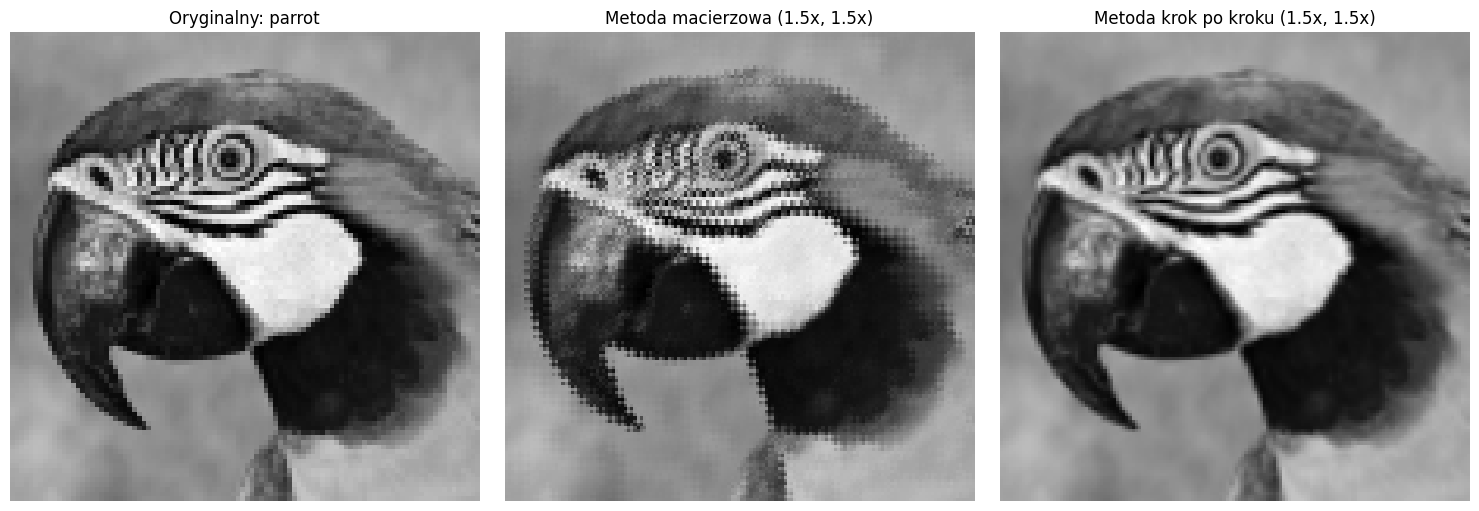

Czas wykonania dla metody macierzowej: 0.13405 s
Czas wykonania dla metody krok po kroku: 0.15569 s
Różnica: 0.02164 s

Test dla obrazu 'parrot', skala: 2.5x, 2.5x


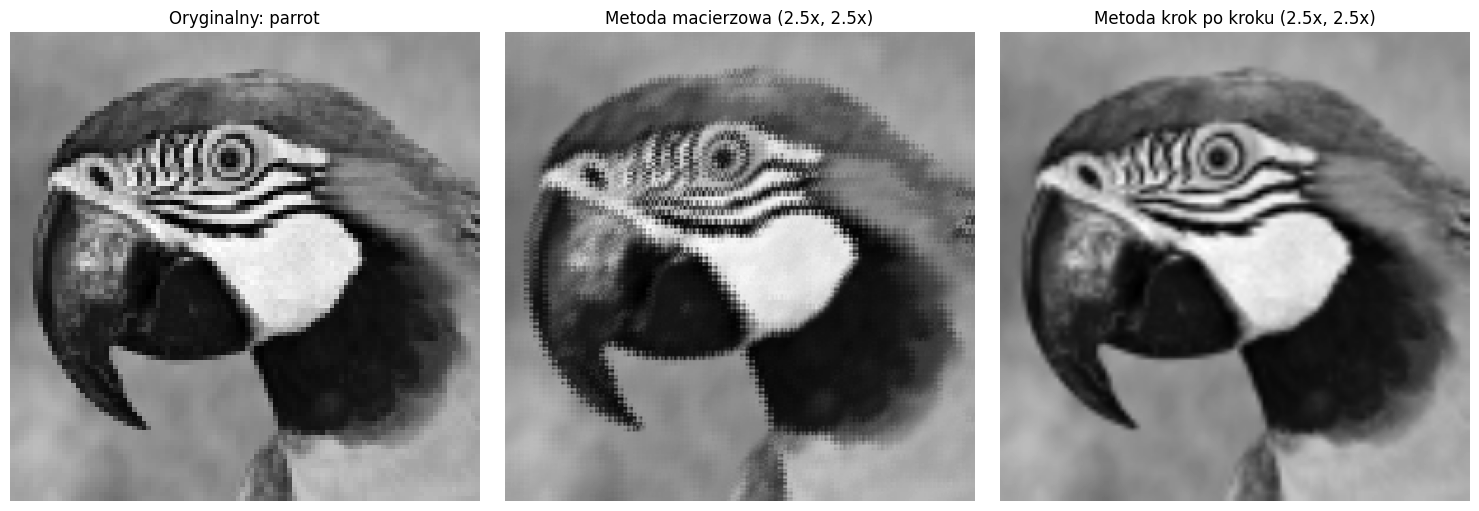

Czas wykonania dla metody macierzowej: 0.39276 s
Czas wykonania dla metody krok po kroku: 0.42402 s
Różnica: 0.03127 s

Test dla obrazu 'parrot', skala: 1.5x, 2.5x


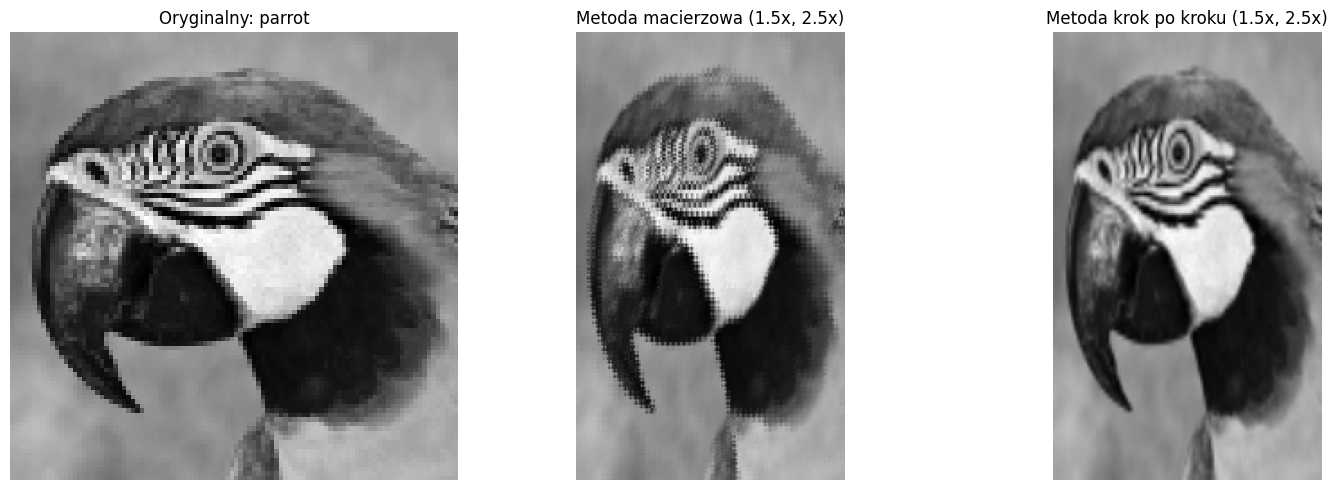

Czas wykonania dla metody macierzowej: 0.22942 s
Czas wykonania dla metody krok po kroku: 0.25072 s
Różnica: 0.02131 s

Test dla obrazu 'parrot', skala: 0.7x, 0.7x


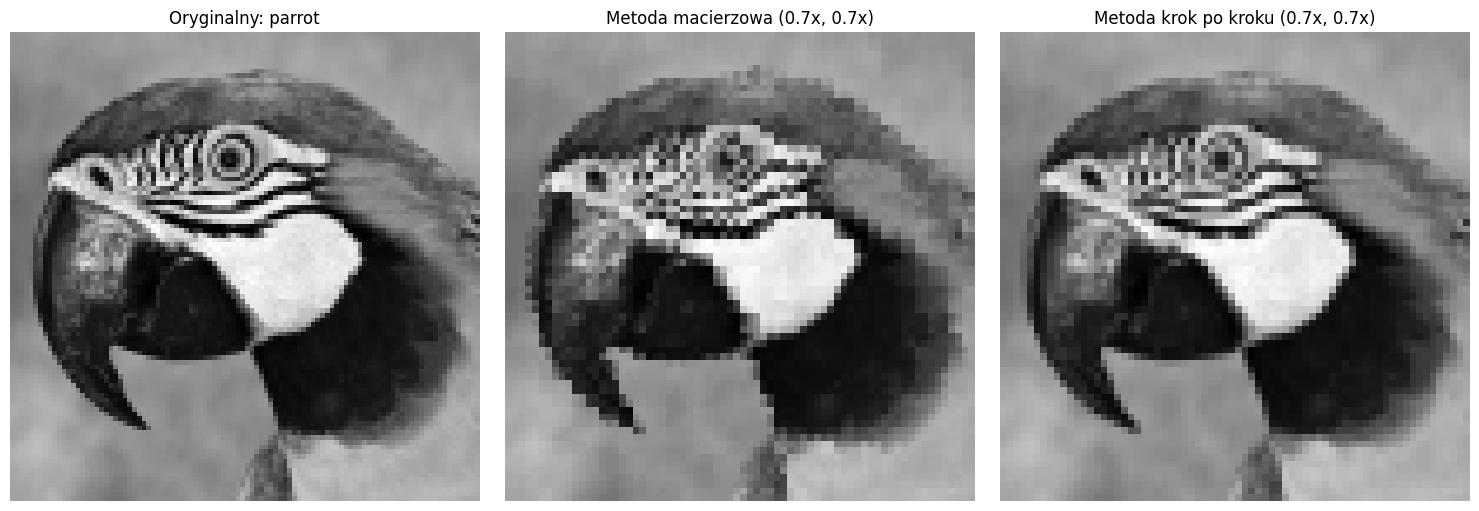

Czas wykonania dla metody macierzowej: 0.03485 s
Czas wykonania dla metody krok po kroku: 0.05077 s
Różnica: 0.01593 s

Test dla obrazu 'clock', skala: 1.5x, 1.5x


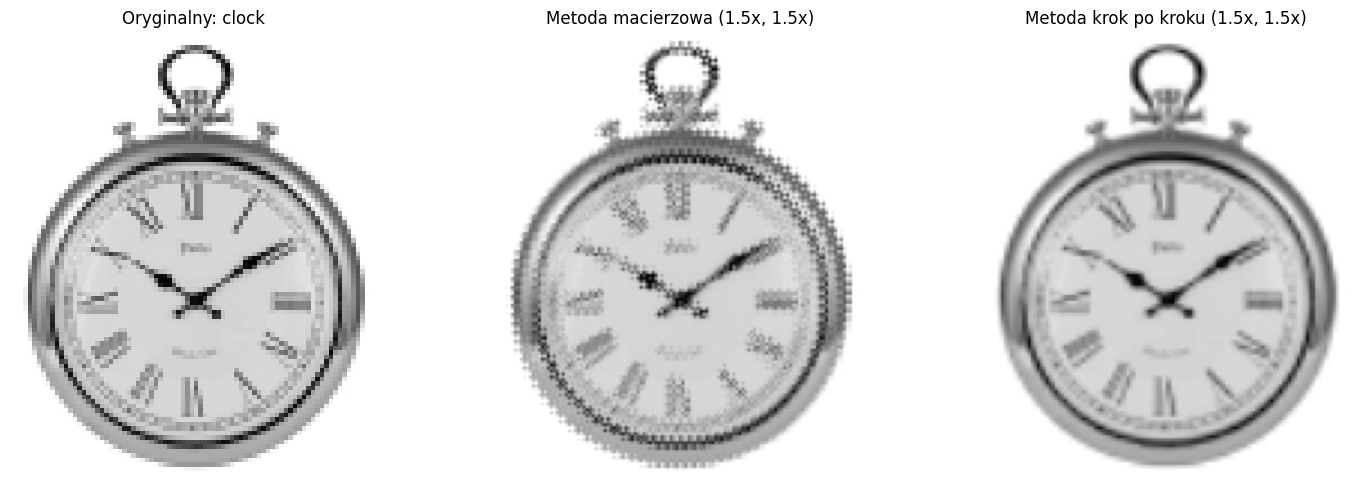

Czas wykonania dla metody macierzowej: 0.10000 s
Czas wykonania dla metody krok po kroku: 0.10478 s
Różnica: 0.00477 s

Test dla obrazu 'chessboard', skala: 1.5x, 1.5x


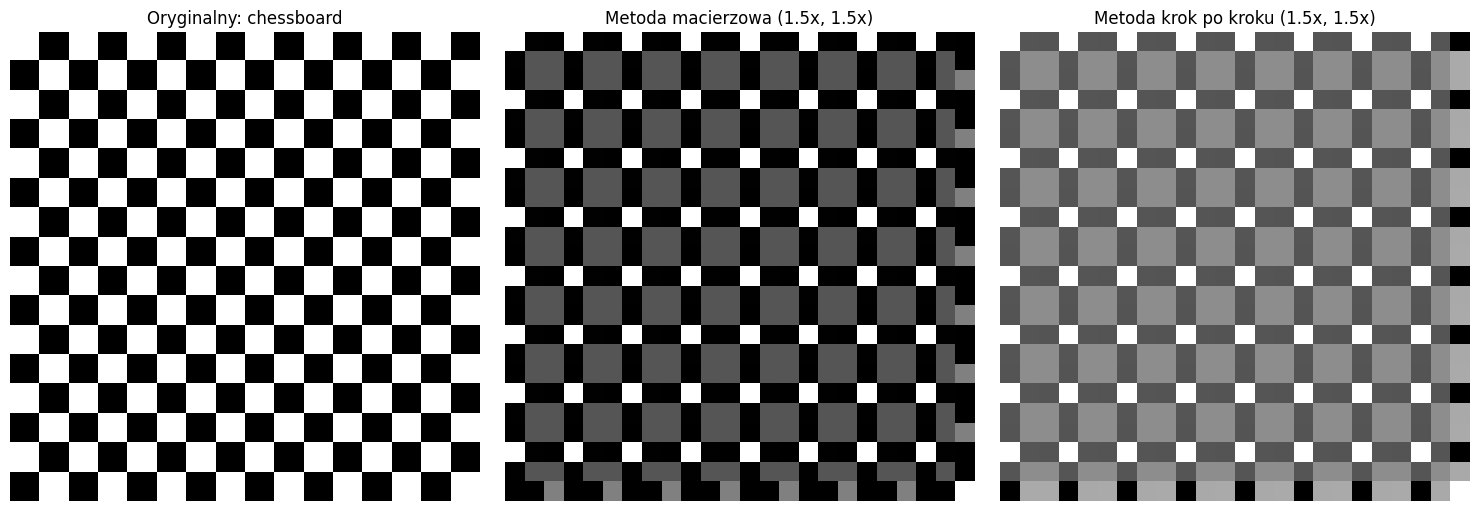

Czas wykonania dla metody macierzowej: 0.00552 s
Czas wykonania dla metody krok po kroku: 0.00266 s
Różnica: 0.00286 s

Test dla obrazu kolorowego 'firetruck', skala: 1.5x, 1.5x


KeyboardInterrupt: 

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def interpolacja_dwuliniowa_optymalna(image, scale_x, scale_y, use_matrix_approach=True):
    """
    Funkcja dokonująca interpolacji obrazu metodą dwuliniową.
    
    Parametry:
    image - obraz wejściowy
    scale_x - współczynnik skalowania w poziomie
    scale_y - współczynnik skalowania w pionie
    use_matrix_approach - wybór podejścia (True - macierzowe, False - krok po kroku)
    
    Zwraca:
    resized_image - przeskalowany obraz
    """
    if len(image.shape) == 2: 
        height, width = image.shape
        is_grayscale = True
    else:  
        height, width, channels = image.shape
        is_grayscale = False
    
    new_height = int(round(height * scale_y))
    new_width = int(round(width * scale_x))
    
    if is_grayscale:
        resized_image = np.zeros((new_height, new_width), dtype=image.dtype)
    else:
        resized_image = np.zeros((new_height, new_width, channels), dtype=image.dtype)
    
    inv_scale_y = height / new_height
    inv_scale_x = width / new_width
    
    for i in range(new_height):
        src_i = i * inv_scale_y
        
        i1 = int(np.floor(src_i))
        i2 = min(i1 + 1, height - 1)
        
        di = src_i - i1
        
        for j in range(new_width):
            src_j = j * inv_scale_x
            
            j1 = int(np.floor(src_j))
            j2 = min(j1 + 1, width - 1)
            
            dj = src_j - j1
            
            if is_grayscale:
                A = image[i1, j1]  # Lewy górny (i1, j1)
                B = image[i1, j2]  # Prawy górny (i1, j2)
                C = image[i2, j2]  # Prawy dolny (i2, j2)
                D = image[i2, j1]  # Lewy dolny (i2, j1)
                
                if use_matrix_approach:
                    # Podejście macierzowe - wzór (7) z instrukcji:
                    # f(ABCD) ≈ [1-di  di] * [[A  D], [B  C]] * [[1-dj], [dj]]
                    v1 = np.array([1 - di, di])
                    v2 = np.array([[1 - dj], [dj]])
                    M = np.array([[A, D], [B, C]])
                    
                    # Wykonaj mnożenie macierzowe
                    result = np.dot(np.dot(v1, M), v2)[0]
                else:
                    # Podejście krok po kroku - wzory (2), (3) i (4) z instrukcji
                    fAB = (1 - dj) * A + dj * B  # Odpowiada wzorowi (2)
                    fCD = (1 - dj) * D + dj * C  # Odpowiada wzorowi (3)
                    
                    # Interpolacja pionowa (wzór 4)
                    result = (1 - di) * fAB + di * fCD  # Odpowiada wzorowi (4)
                
                resized_image[i, j] = result
            else:
                
                for c in range(channels):
                    A = image[i1, j1, c]
                    B = image[i1, j2, c]
                    C = image[i2, j2, c]
                    D = image[i2, j1, c]
                    
                    if use_matrix_approach:
                        v1 = np.array([1 - di, di])
                        v2 = np.array([[1 - dj], [dj]])
                        M = np.array([[A, D], [B, C]])
                        result = np.dot(np.dot(v1, M), v2)[0]
                    else:
                        fAB = (1 - dj) * A + dj * B
                        fCD = (1 - dj) * D + dj * C
                        result = (1 - di) * fAB + di * fCD
                    
                    resized_image[i, j, c] = result
    
    return resized_image

# Funkcja pomocnicza do wyświetlania porównania
def show_comparison(image, interpolated1, interpolated2, title, scale_x, scale_y):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title('Oryginalny: ' + title)
    if len(image.shape) == 2:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(image)
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title(f'Metoda macierzowa ({scale_x}x, {scale_y}x)')
    if len(interpolated1.shape) == 2:
        plt.imshow(interpolated1, cmap='gray')
    else:
        plt.imshow(interpolated1)
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title(f'Metoda krok po kroku ({scale_x}x, {scale_y}x)')
    if len(interpolated2.shape) == 2:
        plt.imshow(interpolated2, cmap='gray')
    else:
        plt.imshow(interpolated2)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def compare_execution_time(image, scale_x, scale_y):
    import time
    
    start = time.time()
    _ = interpolacja_dwuliniowa_optymalna(image, scale_x, scale_y, use_matrix_approach=True)
    matrix_time = time.time() - start
    
    start = time.time()
    _ = interpolacja_dwuliniowa_optymalna(image, scale_x, scale_y, use_matrix_approach=False)
    step_time = time.time() - start
    
    print(f"Czas wykonania dla metody macierzowej: {matrix_time:.5f} s")
    print(f"Czas wykonania dla metody krok po kroku: {step_time:.5f} s")
    print(f"Różnica: {abs(matrix_time - step_time):.5f} s")

parrot = cv2.imread('parrot.bmp', cv2.IMREAD_GRAYSCALE)
clock = cv2.imread('clock.bmp', cv2.IMREAD_GRAYSCALE)
chessboard = cv2.imread('chessboard.bmp', cv2.IMREAD_GRAYSCALE)
firetruck = cv2.imread('firetruck.jpg')
if firetruck is not None:
    firetruck = cv2.cvtColor(firetruck, cv2.COLOR_BGR2RGB)

image_tests = [
    {"image": parrot, "name": "parrot", "scale_x": 1.5, "scale_y": 1.5},
    {"image": parrot, "name": "parrot", "scale_x": 2.5, "scale_y": 2.5},
    {"image": parrot, "name": "parrot", "scale_x": 1.5, "scale_y": 2.5},
    {"image": parrot, "name": "parrot", "scale_x": 0.7, "scale_y": 0.7},
    {"image": clock, "name": "clock", "scale_x": 1.5, "scale_y": 1.5},
    {"image": chessboard, "name": "chessboard", "scale_x": 1.5, "scale_y": 1.5}
]

for test in image_tests:
    img = test["image"]
    name = test["name"]
    scale_x = test["scale_x"]
    scale_y = test["scale_y"]
    
    print(f"\nTest dla obrazu '{name}', skala: {scale_x}x, {scale_y}x")
    
    interpolated_matrix = interpolacja_dwuliniowa_optymalna(img, scale_x, scale_y, use_matrix_approach=True)
    
    interpolated_step = interpolacja_dwuliniowa_optymalna(img, scale_x, scale_y, use_matrix_approach=False)
    
    show_comparison(img, interpolated_matrix, interpolated_step, name, scale_x, scale_y)
    
    compare_execution_time(img, scale_x, scale_y)

if firetruck is not None:
    print("\nTest dla obrazu kolorowego 'firetruck', skala: 1.5x, 1.5x")
    scale_x, scale_y = 1.5, 1.5
    
    interpolated_matrix = interpolacja_dwuliniowa_optymalna(firetruck, scale_x, scale_y, use_matrix_approach=True)
    interpolated_step = interpolacja_dwuliniowa_optymalna(firetruck, scale_x, scale_y, use_matrix_approach=False)
    
    show_comparison(firetruck, interpolated_matrix, interpolated_step, "firetruck", scale_x, scale_y)
    compare_execution_time(firetruck, scale_x, scale_y)

## Interpolacja w OpenCV

W OpenCV dostępna jest funkcja `resize`, która służy do zmiany rozmiaru obrazka.
Składnia jest następująca `dst = cv2.resize(	src, dsize[, dst[, fx[, fy[, interpolation]]]] )`, gdzie `det` to obraz wynikowy, `src` obraz źródłowy, `dsize` rozmiar docelowy (ew. można podać współczynniki skalowania dla poszczególnych osi: `fx,fy`), `interpolation` metoda interpolacji.
Metod podstawowych dostępnych jest 5:
- najbliższego sąsiada - ` cv2.INTER_NEAREST`,
- dwuliniowa - ` cv2.INTER_LINEAR`,
- dwukubiczna - ` cv2.INTER_CUBIC`,
- *area* - ` cv2.INTER_AREA`,
- *lanczos4* - ` cv2.INTER_LANCZOS4`.

Przeprowadzimy następujący eksperyment: obraz (o większej niż dotąd rozdzielczości) przeskalujemy każdą z metod -- zwiększymy i zmniejszymy jego rozdzielczość. Dodamy też pomiar czasu realizacji obliczeń.

Obraz: TODO


Proszę stworzyć funkcję, która jako argumenty przyjmuje obraz oraz dwa współczynniki skalujące, a wewnątrz przeprowadzone zostaną interpolacje, pomiar czasu oraz wizualizacja (można wypisać czas w tytule rysunku).

Pomiar czasu:
```{python}
from timeit import default_timer as timer
start = timer()
# ...
end = timer()
print(end - start)
```

Wykonaj eksperyment dla kilku różnych skal, przeanalizuj czasy obliczeń.

In [ ]:
import cv2
import matplotlib.pyplot as plt
from timeit import default_timer as timer

def interpolacjaOpenCV(img, scale_x, scale_y):
    """
    Przeskalowuje obraz 'img' o współczynniki (scale_x, scale_y)
    z użyciem różnych metod interpolacji OpenCV, mierzy czasy
    i wyświetla wyniki wraz z tabelką podsumowującą.
    """
    methods = [
        (cv2.INTER_NEAREST,  "INTER_NEAREST"),
        (cv2.INTER_LINEAR,   "INTER_LINEAR"),
        (cv2.INTER_CUBIC,    "INTER_CUBIC"),
        (cv2.INTER_AREA,     "INTER_AREA"),
        (cv2.INTER_LANCZOS4, "INTER_LANCZOS4"),
    ]
    
    (h, w) = img.shape[:2]
    dim = (int(w * scale_x), int(h * scale_y))
    
    times = []  # do przechowywania czasów obliczeń

    for method, name in methods:
        start = timer()
        resized = cv2.resize(img, dim, interpolation=method)
        end = timer()
        elapsed = end - start
        
        times.append((name, elapsed))
        
        plt.imshow(resized, cmap="gray")
        plt.title(f"{name} - Czas: {elapsed:.6f}s")
        plt.xticks([]), plt.yticks([])
        plt.show()
    
    # PODSUMOWANIA
    print(f"\n=== Podsumowanie czasów dla skali ({scale_x}x, {scale_y}y) ===")
    print(f"{'Metoda':<15} | {'Czas [s]':>10}")
    print("-" * 29)
    for method_name, elapsed_time in times:
        print(f"{method_name:<15} | {elapsed_time:>10.6f}")
    print()

if __name__ == "__main__":
    fire_truck = cv2.imread('firetruck.jpg', cv2.IMREAD_GRAYSCALE)
    if fire_truck is None:
        raise FileNotFoundError("Nie znaleziono pliku 'firetruck.jpg'")

    interpolacjaOpenCV(fire_truck, 0.5, 0.5)
    interpolacjaOpenCV(fire_truck, 1.0, 0.5)
    interpolacjaOpenCV(fire_truck, 2.0, 2.0)
    interpolacjaOpenCV(fire_truck, 1.5, 1.5)
    interpolacjaOpenCV(fire_truck, 0.3, 0.7)


## Analiza porównawcza

- **Interpolacja najbliższego sąsiada (INTER_NEAREST):**  
  Zwykle najszybsza metoda, co potwierdzają czasami rzędu setnych tysiącej sekundy przy mniejszych skalach. Jednakże jakość obrazu jest zazwyczaj niższa, co może być zauważalne przy dużym powiększeniu.

- **Interpolacja liniowa (INTER_LINEAR):**  
  Czas wykonania metody jest niewiele większy niż dla INTER_NEAREST, a jakość obrazu znacząco lepsza. W większości przypadków stanowi dobry kompromis między szybkością a jakością.

- **Interpolacja sześcienna (INTER_CUBIC):**  
  Zwiększony czas obliczeń w porównaniu do liniowej jest uzasadniony lepszą jakością obrazu, szczególnie przy dużych powiększeniach. Czas może być jednak nieco większy, co widać np. przy skalowaniu 2.0x2.0.

- **Metoda INTER_AREA:**  
  Przy mniejszym powiększeniu (skalowanie w dół) metoda ta często działa bardzo dobrze i czasami szybciej niż inne metody przy podobnej jakości. Przykładem może być skala 1.5x1.5, gdzie INTER_AREA osiąga najniższy czas.

- **Interpolacja LANCZOS4 (INTER_LANCZOS4):**  
  Najbardziej czasochłonna metoda ze względu na skomplikowane obliczenia, ale może dawać lepsze rezultaty w przypadkach, gdy zależy nam na najwyższej jakości. Jej czas wykonania wzrasta zauważalnie przy większych skalach (np. 2.0x2.0).

## Wnioski

- **Szybkość vs. Jakość:**  
  Wybór metody interpolacji powinien być oparty na kompromisie między szybkością a jakością. Dla aplikacji czasu krytycznych (np. przetwarzanie w czasie rzeczywistym) można rozważyć INTER_NEAREST lub INTER_LINEAR, natomiast w sytuacjach, gdy jakość jest priorytetem, warto wybrać INTER_CUBIC lub INTER_LANCZOS4.

- **Skala Obrazu:**  
  Czas wykonania rośnie wraz z powiększeniem obrazu. Przy większych skalach różnice między metodami są bardziej zauważalne, dlatego istotne jest dobranie metody odpowiedniej do konkretnego zadania.

- **Praktyczne Zastosowanie:**  
  Testy wykonane na różnych skalach pozwalają lepiej zrozumieć wpływ wybranej metody interpolacji na czas wykonania oraz jakość przeskalowanego obrazu. Wszystkie testy potwierdzają, że metody wyższej jakości (INTER_CUBIC, INTER_LANCZOS4) są bardziej czasochłonne.

Podsumowując, przedstawiony kod umożliwia dokładną analizę i porównanie czasu wykonania różnych metod interpolacji dostępnych w OpenCV, co pozwala wybrać najodpowiedniejszą metodę w zależności od wymagań aplikacji.

## Rozdzielczość (dpi)

Omówioną wcześniej rozdzielczość przestrzenną (rozmiar) należy utożsamiać z rozmiarem macierzy w której zapisany jest obraz.
W tym ujęciu rozmiar pojedynczego piksela nie ma specjalnego znaczenia.
Problem pojawia się, kiedy obraz trzeba wyświetlić lub wydrukować.
Wtedy pojedynczy piksel staje się ,,obiektem fizycznym'' i musi mieć swój rozmiar (wysokość/szerokość/powierzchnię).

Parametr dpi (ang. *dots per inch*) określa liczbę kropek (pikseli), która mieści się na jednym calu (25,4 mm) długości/szerokości.
Dopiero kombinacja rozmiaru i rozdzielczości określa nam rzeczywisty rozmiar obrazu jaki uzyskamy na wydruku.

Dpi staje się istotne w przypadku drukowania, gdyż wyświetlanie na monitorze odbywa się zazwyczaj 1 piksel obrazka = 1 piksel na monitorze (w przypadku maksymalnej rozdzielczości wspieranej przez monitor), ew. następuje automatyczne skalowanie.

Wpływ rozdzielczości można zademonstrować w następujący sposób:
- wczytaj obraz *lena.bmp*.  Ma on rozmiar $512 \times 512$.
- wykorzystując funkcję `imresize` stwórz obrazy o rozmiarach $256 \times 256$, $128 \times 128$, $64 \times 64$ - metoda interpolacji jest w tym wypadku mniej istotna.
- wyświetl obrazy wymuszając zachowanie na ekranie wejściowej rozdzielczości $512 \times 512$. W przypadku biblioteki *matplotlib* ta funkcjonalność jest domyślna.

Proszę zaobserwować co dzieję się z obrazkiem.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys

try:
    lena = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)
    if lena is None:
        raise FileNotFoundError("Nie znaleziono pliku 'lena.bmp'.")
except Exception as e:
    print(f"Błąd wczytywania obrazu: {e}")
    print("Program zostanie zakończony.")
    sys.exit(1)

lena_256 = cv2.resize(lena, (256, 256), interpolation=cv2.INTER_NEAREST)
lena_128 = cv2.resize(lena, (128, 128), interpolation=cv2.INTER_NEAREST)
lena_64  = cv2.resize(lena, (64, 64),  interpolation=cv2.INTER_NEAREST)

def show_image_with_dpi_in_separate_window(img, title):
    """
    Wyświetla obraz w osobnym oknie, oblicza szacunkowe DPI i dodaje tę informację o rozmiarze obrazka.
    """
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(1, 1, 1)
    
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

    height, width = img.shape[:2]

    fig_width_in, _ = fig.get_size_inches()
    
    dpi_estimate = width / fig_width_in

    text_info = f"Rozmiar: {width}x{height} px\nDPI: {dpi_estimate:.1f}"
    ax.text(
        0.02, 0.95, text_info, transform=ax.transAxes,
        fontsize=9, color='white',
        bbox=dict(facecolor='black', alpha=0.6),
        verticalalignment='top', horizontalalignment='left'
    )

    plt.show()
    


show_image_with_dpi_in_separate_window(lena,     "Oryginalny 512x512")
show_image_with_dpi_in_separate_window(lena_256, "Zmniejszony 256x256")
show_image_with_dpi_in_separate_window(lena_128, "Zmniejszony 128x128")
show_image_with_dpi_in_separate_window(lena_64,  "Zmniejszony 64x64")

# Podsumowanie i Wnioski – Rozdzielczość (DPI) i Jakość Obrazu

W przedstawionym zadaniu analizowana jest kwestia zmiany rozdzielczości obrazu (wymiary macierzy pikseli) oraz jej wpływ na końcową jakość przy wyświetlaniu lub drukowaniu, gdzie pojawia się parametr DPI (*dots per inch*).  

## Omówienie zagadnienia

- **Rozmiar macierzy a DPI:**  
  Rozmiar obrazu w postaci macierzy (np. 512×512 pikseli) definiuje ilość informacji, które są zapisane, jednak nie mówi nic o fizycznym rozmiarze wyświetlanego lub drukowanego obrazu. DPI określa, ile pikseli przypada na jeden cal, a zatem decyduje o faktycznym wymiarze obrazu w przestrzeni fizycznej.  
  - Przykładowo, obraz oryginalny (512×512) przy wyświetlaniu w rozmiarze odpowiadającym tej macierzy będzie przedstawiał piksele w rzeczywistych wymiarach wynikających z ustawień DPI monitora czy drukarki.
  - W miarę zmniejszania rozmiaru macierzy (np. do 256×256, 128×128, 64×64) i wyświetlania ich w stałej ramce (np. odpowiadającej 512×512 pikseli), każdy piksel musi być "rozciągnięty" lub powielony, co wpływa na jakość obrazu.

- **Efekty przy zmniejszaniu rozdzielczości:**  
  - **Utrata szczegółów:** Zmniejszając rozmiar obrazu, redukujemy liczbę pikseli, co powoduje utratę drobnych detali i precyzyjnego odwzorowania oryginału.  
  - **Pikselizacja:** Przy wyświetlaniu zmniejszonego obrazu w dużej ramce (np. 512×512), pojedyncze piksele stają się widoczne jako większe "kostki", co obniża estetykę wizualną obrazu.

- **Wpływ DPI na percepcję obrazu:**  
  - Parametr DPI pozwala określić, jak gęsto piksele będą rozmieszczone w przestrzeni. Wyższy DPI oznacza, że piksele są mniejsze i bardziej gęsto upakowane, co może poprawić ostrość i szczegółowość obrazu.  
  - W zadaniu, mimo że obraz jest wyświetlany z wymuszeniem wejściowej rozdzielczości (512×512), zmniejszenie liczby pikseli wpływa na szacunkowe DPI, co jest widoczne w nałożonym opisie. Obrazy o niższej liczbie pikseli mają niższą wartość DPI, co odzwierciedla ich mniejszą gęstość pikseli, a co za tym idzie, mniejszą precyzję odwzorowania detali.

## Ogólne Wnioski

- **Jakość obrazu przy skalowaniu:**  
  Metoda wykorzystana w kodzie (zmiana rozmiaru przy użyciu `cv2.resize` z interpolacją najbliższego sąsiada) celowo nie skupia się na uzyskaniu wysokiej jakości wizualnej, ale raczej na zademonstrowaniu efektu zmiany liczby pikseli przy zachowaniu oryginalnego rozmiaru wyświetlania.  
  - Oryginalny obraz (512×512) prezentuje pełen zbiór detali.
  - Obrazy zmniejszone do 256×256, 128×128 i 64×64 uzyskują coraz bardziej „pikselowany” wygląd, gdyż każda redukcja rozdzielczości prowadzi do utraty informacji wizualnej.

- **Praktyczne zastosowanie DPI:**  
  W kontekście przygotowań do druku lub wyświetlania w specyficznych warunkach, DPI staje się kluczowym parametrem. Nawet przy zachowaniu tych samych wymiarów wyświetlania (np. 512×512 pikseli na ekranie), różnice w liczbie faktycznie dostępnych pikseli wpływają na ostateczną jakość i ostrość obrazu.

- **Podsumowanie efektu:**  
  Zastosowanie różnych rozmiarów macierzy przy wyświetlaniu w stałym układzie (512×512) umożliwia obserwację, że im mniejsza liczba pikseli, tym mniej szczegółowy i bardziej pikselowany jest wynikowy obraz. Efekt ten ilustruje, dlaczego przy drukowaniu czy profesjonalnym wyświetlaniu konieczne jest dobranie odpowiedniego DPI oraz zachowanie optymalnej rozdzielczości oryginalnego obrazu.

Podsumowując, kod i analiza demonstrują, jak kluczowym aspektem wpływającym na ostateczną jakość wizualną obrazu jest nie tylko liczba pikseli (rozmiar macierzy), ale także sposób ich rozmieszczenia (DPI). Optymalny kompromis między rozmiarem macierzy a fizycznym wyświetleniem obrazu decyduje o zachowaniu szczegółowości i estetyki obrazu.

## Liczba poziomów jasności

Dla obrazów w skali szarości pojedynczy piksel zwykle zapisuje się na 8 bitach, co daje 256 rozróżnialnych poziomów szarości.
Dla większości zastosowań wartość ta jest wystarczająca (choć są kamery o wyjścu 12 lub 16 bitów).
Jednak oko ludzkie nie potrafi rozróżnić wszystkich 256 poziomów jasności (jest za mało czułe).
Zazwyczaj człowiek rozróżnia 20-30 poziomów szarości (to ile i jakie dokładnie rozróżnia, zależy od konkretnego oświetlenia sceny i cech osobniczych).

W poniższych krokach zademonstrujemy omówione zjawisko:
- wczytaj (użyj) obrazu _lena_,
- wykorzystując znaną funkcję `normalize` zmień liczbę poziomów szarości z 0-255 na:
    * 0-31
    * 0-15
    * 0-7
    * 0-3
    * 0-1 (binaryzacja)
- rezultaty wyświetl na wspólnym rysunku.

Podpowiedzi:
- trzeba przygotować tablice na obrazki np, `I_31 = np.zeros(I.shape,'uint8')`,
- prawidłowe użycie funkcji normalize `cv2.normalize(I,I_31,0,31,cv2.NORM_MINMAX)`,
- przykładowe wyświetlanie `axsHist[0,1].imshow(I, 'gray', vmin=0, vmax=31)`.

Czy rezultaty eksperymentu pasują do teorii o rozpoznawaniu przez człowieka ograniczonego zakresu poziomów jasności?
Wizualne porównanie których obrazów o tym świadczy ?

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys

def main():
    try:
        lena = cv2.imread('lena.bmp')
        if lena is None:
            raise FileNotFoundError("Nie znaleziono pliku 'lena.bmp'")
        lena = cv2.cvtColor(lena, cv2.COLOR_BGR2GRAY)
    except Exception as e:
        print(f"Błąd wczytywania obrazu: {e}")
        print("Program zostanie zakończony.")
        sys.exit(1)

    lena_org = np.zeros(lena.shape, dtype=np.uint8)  # Oryginał o 256 poziomach (0-255)
    I_31 = np.zeros(lena.shape, dtype=np.uint8)
    I_15 = np.zeros(lena.shape, dtype=np.uint8)
    I_7  = np.zeros(lena.shape, dtype=np.uint8)
    I_3  = np.zeros(lena.shape, dtype=np.uint8)
    I_1  = np.zeros(lena.shape, dtype=np.uint8)

    cv2.normalize(lena, lena_org, 0, 255, cv2.NORM_MINMAX)
    cv2.normalize(lena, I_31, 0, 31, cv2.NORM_MINMAX)
    cv2.normalize(lena, I_15, 0, 15, cv2.NORM_MINMAX)
    cv2.normalize(lena, I_7,  0, 7,  cv2.NORM_MINMAX)
    cv2.normalize(lena, I_3,  0, 3,  cv2.NORM_MINMAX)
    cv2.normalize(lena, I_1,  0, 1,  cv2.NORM_MINMAX)

    images = [
        (lena_org, "Oryginał: 256 poziomów (0-255)", 0, 255),
        (I_31, "Liczba poziomów: 32 (0-31)", 0, 31),
        (I_15, "Liczba poziomów: 16 (0-15)", 0, 15),
        (I_7, "Liczba poziomów: 8 (0-7)", 0, 7),
        (I_3, "Liczba poziomów: 4 (0-3)", 0, 3),
        (I_1, "Liczba poziomów: 2 (0-1) - binaryzacja", 0, 1)
    ]

    for img, title, vmin, vmax in images:
        plt.figure()
        plt.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        plt.title(title)
        plt.axis('off')
    
    plt.show()

    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Wpływ liczby poziomów jasności na percepcję obrazu', fontsize=16)

    for idx, (img, title, vmin, vmax) in enumerate(images):
        ax = axs[idx // 3, idx % 3]
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

if __name__ == '__main__':
    main()

# Podsumowanie Eksperymentu – Liczba Poziomów Jasności

W powyższym eksperymencie obraz "lena" został przetworzony na różne zakresy poziomów szarości przy użyciu funkcji `cv2.normalize`. Przy próbie przedstawienia obrazu za pomocą różnych zakresów (256, 32, 16, 8, 4, 2 poziomów), uzyskano następujące obserwacje:

- **Oryginał (256 poziomów):**  
  Obraz posiada pełną gamę odcieni szarości, co pozwala na płynne przejścia tonalne i wysoką szczegółowość.

- **Obraz z 32 poziomami (0-31):**  
  Przekazuje większość informacji tonalnych. Przy takich ustawieniach widoczna jest spójność i ciągłość przejść, co zbliża się do zakresu, który jest wystarczający dla ludzkiego oka – człowiek zazwyczaj rozróżnia od 20 do 30 różnych odcieni szarości.

- **Obraz z 16, 8, 4 poziomami:**  
  W miarę redukcji liczby poziomów, obraz staje się coraz bardziej uproszczony. Utrata detali i płynności tonalnej jest bardziej widoczna, co może powodować efekt "stemplowania" barw. Efekt ten wskazuje na ograniczenie zdolności reprodukcji subtelnych różnic, co odpowiada teoretycznym ograniczeniom percepcji przez ludzkie oko.

- **Obraz z 2 poziomami (binaryzacja):**  
  Obraz jest drastycznie uproszczony – jedynie dwa poziomy szarości (czarne i białe) powodują całkowitą utratę detali i gradacji, co jest znacznie poniżej percepcyjnych możliwości ludzkiego wzroku.

## Wnioski

- **Zgodność z teorią:**  
  Wyniki eksperymentu potwierdzają teoretyczne ograniczenie percepcji ludzkiego oka. Człowiek jest w stanie rozróżnić około 20-30 odcieni szarości, co oznacza, że obrazy z 32 poziomami (0-31) zachowują większość przydatnych informacji wizualnych i są wystarczające dla codziennej percepcji.

- **Znaczenie liczby poziomów:**  
  Zmniejszenie liczby poziomów szarości wpływa na drastyczną utratę detali wizualnych i w konsekwencji na jakość prezentowanego obrazu. Obrazy o bardzo niskiej liczbie poziomów (np. 4 lub 2) nie oddają subtelnych różnic tonacyjnych, co sprawia, że stają się one nieadekwatne do realistycznej prezentacji sceny.

- **Praktyczna obserwacja:**  
  Wizualne porównanie pojedynczych obrazów, a także obrazów zestawionych na wspólnym rysunku, wyraźnie ilustruje, że zbyt duża redukcja liczby poziomów szarości powoduje zanik płynnych przejść tonalnych, co dowodzi, że o ile 256 odcieni jest technicznie możliwych, dla celów wizualnych i perceptualnych wystarczające jest znacznie mniejsze spektrum.

Podsumowując, eksperyment pokazuje, że chociaż technicznie możemy uzyskać 256 poziomów szarości, ludzka percepcja jest ograniczona i w praktyce wystarczające są zakresy rzędu około 32 poziomów. Redukcja poziomów poniżej tego zakresu prowadzi do zauważalnej degradacji jakości obrazu, co potwierdza teoretyczne założenia dotyczące ludzkiej percepcji odcieni.